# E-Commerce Customer Intelligence & Revenue Optimization

- <b>Part 1: Data Loading & Initial Understanding

In [2]:
# Import libraries
import pandas as pd
import numpy as np

In [3]:
# Load the dataset
df = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")

In [4]:
# Check dataset size
df.shape

(17049, 18)

In [5]:
# Check column names
df.columns.tolist()

['Order_ID',
 'Customer_ID',
 'Date',
 'Age',
 'Gender',
 'City',
 'Product_Category',
 'Unit_Price',
 'Quantity',
 'Discount_Amount',
 'Total_Amount',
 'Payment_Method',
 'Device_Type',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Is_Returning_Customer',
 'Delivery_Time_Days',
 'Customer_Rating']

In [6]:
# Preview the data
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [7]:
# Understand data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [8]:
# Basic statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,17049.0,34.945745,11.046855,18.00,26.00,35.00,42.00,75.00
Unit_Price,17049.0,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01
Quantity,17049.0,3.011379,1.417027,1.00,2.00,3.00,4.00,5.00
Discount_Amount,17049.0,69.788135,240.704662,0.00,0.00,0.00,32.71,6538.29
Total_Amount,17049.0,1277.438711,2358.436375,6.21,172.97,455.85,1267.75,37852.05
Session_Duration_Minutes,17049.0,14.535633,2.925524,4.00,13.00,15.00,17.00,26.00
Pages_Viewed,17049.0,9.003109,2.259954,1.00,7.00,9.00,11.00,18.00
Delivery_Time_Days,17049.0,6.503607,3.488787,1.00,4.00,6.00,8.00,25.00
Customer_Rating,17049.0,3.899408,1.128803,1.00,3.00,4.00,5.00,5.00


- <b>Part 2: Data Cleaning

In [9]:
# Check missing values
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Check data types
df.dtypes

Order_ID                     object
Customer_ID                  object
Date                         object
Age                           int64
Gender                       object
City                         object
Product_Category             object
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method               object
Device_Type                  object
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object

In [11]:
# Check important numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,17049.0,34.945745,11.046855,18.00,26.00,35.00,42.00,75.00
Unit_Price,17049.0,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01
Quantity,17049.0,3.011379,1.417027,1.00,2.00,3.00,4.00,5.00
Discount_Amount,17049.0,69.788135,240.704662,0.00,0.00,0.00,32.71,6538.29
Total_Amount,17049.0,1277.438711,2358.436375,6.21,172.97,455.85,1267.75,37852.05
Session_Duration_Minutes,17049.0,14.535633,2.925524,4.00,13.00,15.00,17.00,26.00
Pages_Viewed,17049.0,9.003109,2.259954,1.00,7.00,9.00,11.00,18.00
Delivery_Time_Days,17049.0,6.503607,3.488787,1.00,4.00,6.00,8.00,25.00
Customer_Rating,17049.0,3.899408,1.128803,1.00,3.00,4.00,5.00,5.00


In [12]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [13]:
df.columns.tolist()

['order_id',
 'customer_id',
 'date',
 'age',
 'gender',
 'city',
 'product_category',
 'unit_price',
 'quantity',
 'discount_amount',
 'total_amount',
 'payment_method',
 'device_type',
 'session_duration_minutes',
 'pages_viewed',
 'is_returning_customer',
 'delivery_time_days',
 'customer_rating']

In [14]:
# Final cleaning check
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  17049 non-null  object 
 1   customer_id               17049 non-null  object 
 2   date                      17049 non-null  object 
 3   age                       17049 non-null  int64  
 4   gender                    17049 non-null  object 
 5   city                      17049 non-null  object 
 6   product_category          17049 non-null  object 
 7   unit_price                17049 non-null  float64
 8   quantity                  17049 non-null  int64  
 9   discount_amount           17049 non-null  float64
 10  total_amount              17049 non-null  float64
 11  payment_method            17049 non-null  object 
 12  device_type               17049 non-null  object 
 13  session_duration_minutes  17049 non-null  int64  
 14  pages_

order_id                    0
customer_id                 0
date                        0
age                         0
gender                      0
city                        0
product_category            0
unit_price                  0
quantity                    0
discount_amount             0
total_amount                0
payment_method              0
device_type                 0
session_duration_minutes    0
pages_viewed                0
is_returning_customer       0
delivery_time_days          0
customer_rating             0
dtype: int64

- <b>Part 3: Exploratory Data Analysis (EDA)

In [15]:
# Dataset overview
df.shape
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,17049.0,34.945745,11.046855,18.00,26.00,35.00,42.00,75.00
unit_price,17049.0,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01
quantity,17049.0,3.011379,1.417027,1.00,2.00,3.00,4.00,5.00
discount_amount,17049.0,69.788135,240.704662,0.00,0.00,0.00,32.71,6538.29
total_amount,17049.0,1277.438711,2358.436375,6.21,172.97,455.85,1267.75,37852.05
session_duration_minutes,17049.0,14.535633,2.925524,4.00,13.00,15.00,17.00,26.00
pages_viewed,17049.0,9.003109,2.259954,1.00,7.00,9.00,11.00,18.00
delivery_time_days,17049.0,6.503607,3.488787,1.00,4.00,6.00,8.00,25.00
customer_rating,17049.0,3.899408,1.128803,1.00,3.00,4.00,5.00,5.00


In [16]:
# Check categorical columns
df.select_dtypes(include="object").nunique().sort_values()

gender                  3
device_type             3
payment_method          5
product_category        8
city                   10
date                  450
customer_id          5000
order_id            17049
dtype: int64

In [17]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


order_id:
order_id
ORD_000001-1    1
ORD_003337-3    1
ORD_003333-3    1
ORD_003333-4    1
ORD_003334-1    1
ORD_003335-1    1
ORD_003335-2    1
ORD_003335-3    1
ORD_003335-4    1
ORD_003336-1    1
Name: count, dtype: int64

customer_id:
customer_id
CUST_04224    10
CUST_03833    10
CUST_04396    10
CUST_00927    10
CUST_02028    10
CUST_01482    10
CUST_02487    10
CUST_04255    10
CUST_00900    10
CUST_02765    10
Name: count, dtype: int64

date:
date
2023-07-29    59
2023-02-14    56
2024-01-15    54
2023-05-25    53
2023-04-17    53
2023-09-23    53
2023-02-11    52
2023-07-15    51
2023-10-26    51
2023-09-09    50
Name: count, dtype: int64

gender:
gender
Female    8613
Male      8176
Other      260
Name: count, dtype: int64

city:
city
Istanbul     4402
Ankara       2422
Izmir        2072
Bursa        1721
Adana        1326
Antalya      1246
Gaziantep    1183
Konya        1120
Kayseri       851
Eskisehir     706
Name: count, dtype: int64

product_category:
product_category
Spo

In [18]:
# Identify the main sales/revenue column
df.columns.tolist()

['order_id',
 'customer_id',
 'date',
 'age',
 'gender',
 'city',
 'product_category',
 'unit_price',
 'quantity',
 'discount_amount',
 'total_amount',
 'payment_method',
 'device_type',
 'session_duration_minutes',
 'pages_viewed',
 'is_returning_customer',
 'delivery_time_days',
 'customer_rating']

In [19]:
# Overall business KPIs
total_sales = df["total_amount"].sum()
average_order_value = df["total_amount"].mean()
total_transactions = df.shape[0]

print("Total Sales:", total_sales)
print("Average Order Value:", average_order_value)
print("Total Transactions:", total_transactions)

Total Sales: 21779052.59
Average Order Value: 1277.4387113613702
Total Transactions: 17049


In [20]:
total_customers = df["customer_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 5000


In [21]:
# Sales by category
category_sales = (
    df.groupby("product_category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

product_category
Electronics      10481897.65
Home & Garden     4023903.94
Sports            3205086.99
Fashion           1577035.70
Toys              1014237.53
Beauty             694437.02
Food               422054.65
Books              360399.11
Name: total_amount, dtype: float64

In [22]:
# Category Revenue Contribution
category_contribution = (
    df.groupby("product_category")["total_amount"]
    .sum()
    .reset_index(name="total_sales")
)

category_contribution["revenue_percentage"] = (
    category_contribution["total_sales"]
    / category_contribution["total_sales"].sum()
    * 100
)

category_contribution = category_contribution.sort_values(
    "total_sales",
    ascending=False
)

category_contribution

,product_category,total_sales,revenue_percentage
2,Electronics,10481897.65,48.128345
5,Home & Garden,4023903.94,18.476028
6,Sports,3205086.99,14.716375
3,Fashion,1577035.70,7.241067
7,Toys,1014237.53,4.656941
0,Beauty,694437.02,3.188555
4,Food,422054.65,1.937893
1,Books,360399.11,1.654797


In [23]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check data type
print(df["date"].dtype)

datetime64[ns]


In [24]:
print("Invalid dates:", df["date"].isna().sum())

Invalid dates: 0


In [62]:
df["order_month"] = df["date"].dt.to_period("M").dt.to_timestamp()

df["cohort_month"] = (
    df.groupby("customer_id")["order_month"]
      .transform("min")
)

In [63]:
df[["customer_id", "date", "order_month", "cohort_month"]].head()

,customer_id,date,order_month,cohort_month
0,CUST_00001,2023-05-29,2023-05-01,2023-05-01
1,CUST_00001,2023-10-12,2023-10-01,2023-05-01
2,CUST_00001,2023-12-05,2023-12-01,2023-05-01
3,CUST_00002,2023-05-11,2023-05-01,2023-05-01
4,CUST_00002,2023-06-16,2023-06-01,2023-05-01


In [25]:
# Monthly Sales Analysis
monthly_sales = (
    df.groupby(df["date"].dt.to_period("M"))["total_amount"]
    .sum()
    .reset_index()
)
monthly_sales["date"] = monthly_sales["date"].dt.to_timestamp()
monthly_sales

,date,total_amount
0,2023-01-01,1311603.21
1,2023-02-01,1409777.29
2,2023-03-01,1458005.58
3,2023-04-01,1499648.03
4,2023-05-01,1483511.61
5,2023-06-01,1380984.94
6,2023-07-01,1560046.14
7,2023-08-01,1510999.75
8,2023-09-01,1502164.37
9,2023-10-01,1536847.33


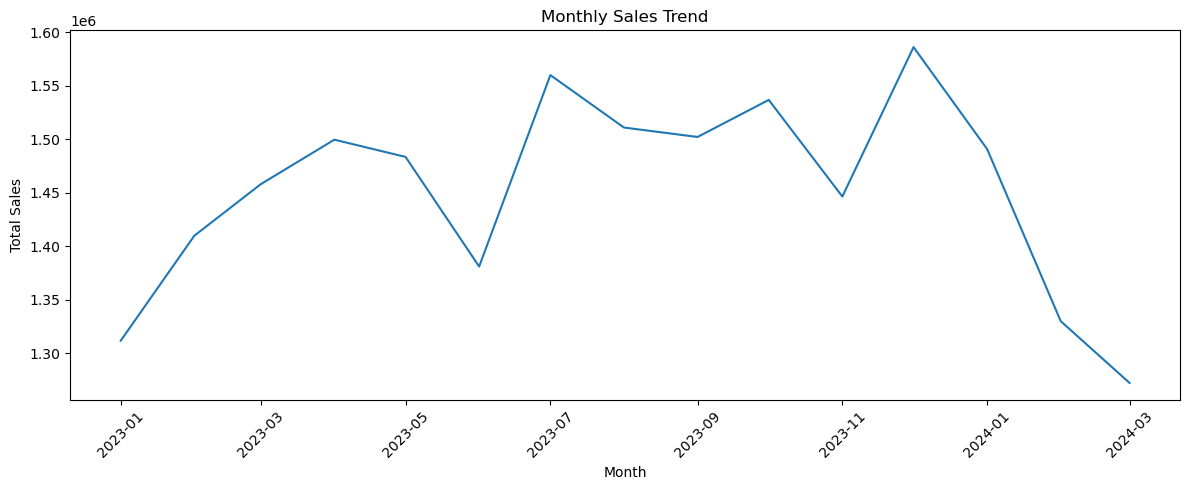

In [26]:
# Monthly Sales Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["total_amount"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Payment-method analysis
payment_analysis = (
    df.groupby("payment_method")
    .agg(
        transactions=("payment_method", "size"),
        sales=("total_amount", "sum")
    )
    .sort_values("sales", ascending=False)
)

payment_analysis

,transactions,sales
payment_method,,
Credit Card,6801,9069714.65
Debit Card,4321,5152182.83
Digital Wallet,3276,4191842.00
Bank Transfer,1763,2311499.25
Cash on Delivery,888,1053813.86


In [28]:
# Customer-level analysis
customer_summary = (
    df.groupby("customer_id")
    .agg(
        total_spend=("total_amount", "sum"),
        transactions=("customer_id", "size"),
        average_order_value=("total_amount", "mean")
    )
    .sort_values("total_spend", ascending=False)
)

customer_summary.head(10)

,total_spend,transactions,average_order_value
customer_id,,,
CUST_01573,50628.15,2,25314.075000
CUST_00197,47324.23,10,4732.423000
CUST_03795,42480.02,3,14160.006667
CUST_00154,41613.83,10,4161.383000
CUST_04219,40608.39,8,5076.048750
CUST_03149,39834.61,6,6639.101667
CUST_03923,38610.82,10,3861.082000
CUST_01164,36842.41,9,4093.601111
CUST_01816,36557.27,9,4061.918889


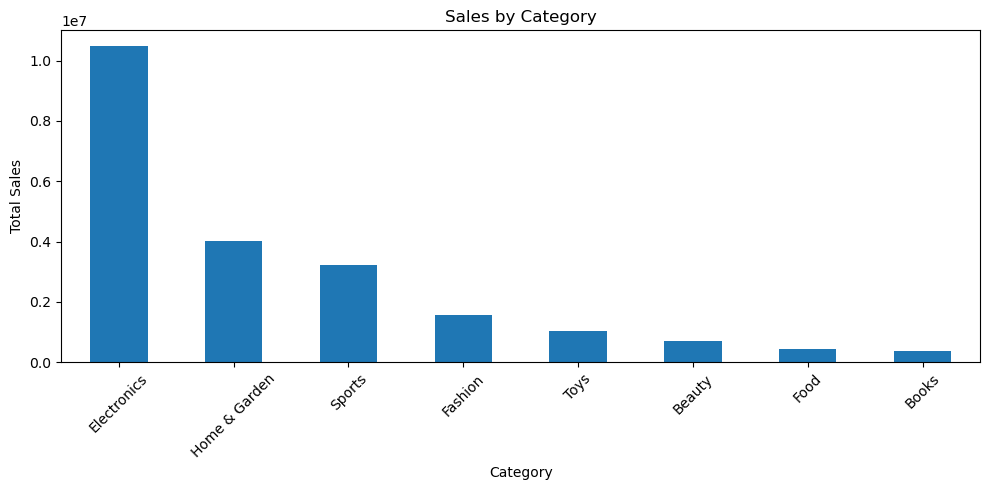

In [29]:
# Create the first visualization
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- <b>Part 4: Revenue & Product Analysis

In [30]:
# Product Category Performance
category_performance = (
    df.groupby("product_category")
      .agg(
          transactions=("customer_id", "size"),
          customers=("customer_id", "nunique"),
          revenue=("total_amount", "sum"),
          avg_order_value=("total_amount", "mean")
      )
      .sort_values("revenue", ascending=False)
)

category_performance

,transactions,customers,revenue,avg_order_value
product_category,,,,
Electronics,2074,1677,10481897.65,5053.952580
Home & Garden,2060,1661,4023903.94,1953.351427
Sports,2248,1767,3205086.99,1425.750440
Fashion,2056,1671,1577035.70,767.040710
Toys,2090,1690,1014237.53,485.281115
Beauty,2212,1753,694437.02,313.940787
Food,2103,1688,422054.65,200.691702
Books,2206,1771,360399.11,163.372217


In [31]:
# Revenue per Customer
revenue_per_customer = (
    df.groupby("customer_id")["total_amount"]
      .sum()
      .mean()
)

print("Average Customer Revenue:", round(revenue_per_customer, 2))

Average Customer Revenue: 4355.81


In [32]:
# Top 10 Revenue Customers
top_customers = (
    df.groupby("customer_id")
      .agg(
          total_spend=("total_amount", "sum"),
          transactions=("customer_id", "size"),
          avg_order_value=("total_amount", "mean")
      )
      .sort_values("total_spend", ascending=False)
      .head(10)
)

top_customers

,total_spend,transactions,avg_order_value
customer_id,,,
CUST_01573,50628.15,2,25314.075000
CUST_00197,47324.23,10,4732.423000
CUST_03795,42480.02,3,14160.006667
CUST_00154,41613.83,10,4161.383000
CUST_04219,40608.39,8,5076.048750
CUST_03149,39834.61,6,6639.101667
CUST_03923,38610.82,10,3861.082000
CUST_01164,36842.41,9,4093.601111
CUST_01816,36557.27,9,4061.918889


- <b>Part 5: Customer Behavior & RFM Analysis

In [33]:
# Customer purchase summary
customer_summary = (
    df.groupby("customer_id")
    .agg(
        total_spend=("total_amount", "sum"),
        total_orders=("customer_id", "count"),
        average_order_value=("total_amount", "mean")
    )
    .reset_index()
)

customer_summary.head()

,customer_id,total_spend,total_orders,average_order_value
0,CUST_00001,2199.63,3,733.210000
1,CUST_00002,809.90,2,404.950000
2,CUST_00003,3030.81,2,1515.405000
3,CUST_00004,383.22,1,383.220000
4,CUST_00005,2422.73,3,807.576667


In [36]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Verify conversion
print("Invalid dates:", df["date"].isna().sum())

Invalid dates: 0


In [39]:
# RFM Analysis
# Recency → How recently did the customer purchase?
# Frequency → How often did they purchase?
# Monetary → How much did they spend?
reference_date = df["date"].max() + pd.Timedelta(days=1)

In [40]:
rfm = (
    df.groupby("customer_id")
    .agg(
        recency=("date", lambda x: (reference_date - x.max()).days),
        frequency=("customer_id", "count"),
        monetary=("total_amount", "sum")
    )
    .reset_index()
)
rfm.head()

,customer_id,recency,frequency,monetary
0,CUST_00001,112,3,2199.63
1,CUST_00002,284,2,809.90
2,CUST_00003,83,2,3030.81
3,CUST_00004,42,1,383.22
4,CUST_00005,279,3,2422.73


In [41]:
# Create RFM scores
rfm["r_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [42]:
# Create overall RFM score
rfm["rfm_score"] = (
    rfm["r_score"].astype(int)
    + rfm["f_score"].astype(int)
    + rfm["m_score"].astype(int)
)

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,CUST_00001,112,3,2199.63,3,3,3,9
1,CUST_00002,284,2,809.90,1,1,2,4
2,CUST_00003,83,2,3030.81,3,1,3,7
3,CUST_00004,42,1,383.22,4,1,1,6
4,CUST_00005,279,3,2422.73,1,3,3,7


In [56]:
# RFM Segment Revenue Contribution

segment_summary = (
    rfm.groupby("customer_segment", as_index=False)
       .agg(total_revenue=("monetary", "sum"))
)

segment_summary["revenue_percentage"] = (
    segment_summary["total_revenue"]
    / segment_summary["total_revenue"].sum()
    * 100
).round(2)

segment_summary = (
    segment_summary
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

segment_summary

,customer_segment,total_revenue,revenue_percentage
0,Champions,9629404.61,44.21
1,Loyal Customers,7257644.62,33.32
2,Potential Loyalists,3750633.63,17.22
3,At Risk,916623.49,4.21
4,Lost Customers,224746.24,1.03


In [57]:
# At-Risk Customers

at_risk_customers = (
    rfm[rfm["customer_segment"] == "At Risk"]
    .sort_values("monetary", ascending=False)
    .reset_index(drop=True)
)

at_risk_customers.head(20)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,CUST_03646,247,1,6659.88,1,1,4,6,At Risk
1,CUST_01391,230,1,6578.58,1,1,4,6,At Risk
2,CUST_01989,366,1,6545.96,1,1,4,6,At Risk
3,CUST_03587,277,1,6437.71,1,1,4,6,At Risk
4,CUST_00034,369,2,6302.30,1,1,4,6,At Risk
5,CUST_00273,424,1,6248.78,1,1,4,6,At Risk
6,CUST_01604,305,1,5879.99,1,1,4,6,At Risk
7,CUST_03351,375,1,5584.26,1,1,4,6,At Risk
8,CUST_03061,250,1,5581.34,1,1,4,6,At Risk
9,CUST_03215,338,1,5557.78,1,1,4,6,At Risk


In [45]:
# Create customer segments
def customer_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost Customers"

rfm["customer_segment"] = rfm["rfm_score"].apply(customer_segment)

In [46]:
rfm["customer_segment"].value_counts()

customer_segment
Potential Loyalists    1392
Loyal Customers        1338
Champions               941
At Risk                 765
Lost Customers          564
Name: count, dtype: int64

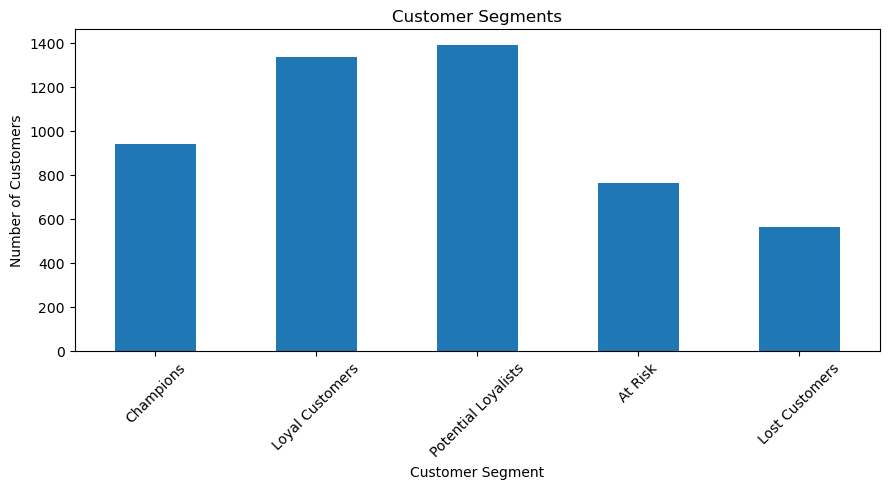

In [48]:
# Visualize customer segments
segment_summary["customers"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Customer Segment Contribution
segment_summary["customer_percentage"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
).round(2)

segment_summary

,customers,total_revenue,avg_revenue,customer_percentage
customer_segment,,,,
Champions,941,9629404.61,10233.161116,18.82
Loyal Customers,1338,7257644.62,5424.248595,26.76
Potential Loyalists,1392,3750633.63,2694.420711,27.84
At Risk,765,916623.49,1198.200641,15.30
Lost Customers,564,224746.24,398.486241,11.28


- <b>Part 6: Retention & Cohort Analysis

In [51]:
#First Purchase Month
df["order_month"] = df["date"].dt.to_period("M")

first_purchase = (
    df.groupby("customer_id")["order_month"]
      .min()
      .reset_index(name="cohort_month")
)

df = df.merge(first_purchase, on="customer_id", how="left")

In [65]:
# Create order month
df["order_month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# Identify each customer's first purchase month
df["cohort_month"] = (
    df.groupby("customer_id")["order_month"]
      .transform("min")
)

In [66]:
# Customer Retention / Cohort Analysis

df["months_since_first_purchase"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

retention = (
    df.groupby(
        ["cohort_month", "months_since_first_purchase"]
    )["customer_id"]
    .nunique()
    .reset_index(name="customers")
)

retention.head()

,cohort_month,months_since_first_purchase,customers
0,2023-01-01,0,1001
1,2023-01-01,1,217
2,2023-01-01,2,223
3,2023-01-01,3,221
4,2023-01-01,4,238


- <b>Part 7: Business Insights & Recommendations

Key Business Insights

1. Revenue is concentrated among selected product categories.
2. High-value customers contribute a significant portion of total revenue.
3. At-Risk customers represent an opportunity for targeted retention campaigns.
4. Payment-method performance can help optimize checkout experience.
5. Customer retention should be monitored by acquisition cohort.

In [68]:
# Save analysis-ready datasets
df.to_csv(
    "ecommerce_customer_behavior_cleaned.csv",
    index=False
)

rfm.to_csv(
    "customer_rfm_analysis.csv",
    index=False
)

monthly_sales.to_csv(
    "monthly_sales_analysis.csv",
    index=False
)

category_contribution.to_csv(
    "category_revenue_contribution.csv",
    index=False
)